# **1-Dataset Checking and Cleaning**

In [11]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd

In [12]:
BASE_DIR = Path.cwd()
DATASET_DIR_NAME = "Dataset"
DATASET_PATH = BASE_DIR / DATASET_DIR_NAME

dataset_override = os.environ.get("DATASET_PATH", "").strip()
if dataset_override:
    DATASET_PATH = Path(dataset_override)

if not DATASET_PATH.exists():
    candidates = []
    for root in {BASE_DIR, BASE_DIR.parent}:
        for name in [DATASET_DIR_NAME, DATASET_DIR_NAME.lower(), "data", "dataset", "datasets"]:
            candidate = root / name
            if candidate.exists() and candidate.is_dir():
                candidates.append(candidate)

    if len(candidates) == 1:
        DATASET_PATH = candidates[0]

print("Base dir:", BASE_DIR)
print("Dataset path:", DATASET_PATH)
if not DATASET_PATH.exists():
    print("Dataset path not found. Set DATASET_PATH env var or update DATASET_DIR_NAME.")

Base dir: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning
Dataset path: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\Dataset


In [6]:
print("Exists:", DATASET_PATH.exists())
if DATASET_PATH.exists():
    body_part_folders = [p.name for p in DATASET_PATH.iterdir() if p.is_dir()]
    print("Body part folders:", body_part_folders)

Exists: True
Body part folders: ['Foot', 'Head', 'Torso', 'Udder']


**Scan folders and collect image information**

In [7]:
image_extensions = [".jpg", ".jpeg", ".png"]

records = []

for body_part_folder in DATASET_PATH.iterdir():
    if body_part_folder.is_dir():
        body_part = body_part_folder.name
        
        for class_folder in body_part_folder.iterdir():
            if class_folder.is_dir():
                class_name = class_folder.name
                
                for image_path in class_folder.iterdir():
                    if image_path.suffix.lower() in image_extensions:
                        records.append({
                            "image_path": str(image_path),
                            "body_part": body_part,
                            "class_name": class_name,
                            "file_name": image_path.name,
                            "extension": image_path.suffix.lower()
                        })

df = pd.DataFrame(records)

print("Total images found:", len(df))

summary = df.groupby(["body_part", "class_name"]).size().reset_index(name="count")
summary

Total images found: 2803


,body_part,class_name,count
0,Foot,Diseased Foot,102
1,Foot,Normal Foot,52
2,Head,Diseased Head,407
3,Head,Normal Head,514
4,Torso,Diseased Torso,498
5,Torso,Normal Torso,501
6,Udder,Diseased Udder,363
7,Udder,Normal Udder,366


**Remove corrupted images from dataframe**

In [8]:
clean_df = df.copy()
clean_df = clean_df.sample(frac=1, random_state=42).reset_index(drop=True)

def check_images(df):
    bad_indices = []
    for idx, row in df.iterrows():
        path = row['image_path']
        try:
            with Image.open(path) as img:
                img.verify() # Verify file integrity
                # Some corruptions only show up when you actually load the data
                img = Image.open(path).convert("RGB")
                img.load() 
        except Exception as e:
            print(f"Corrupt image at index {idx}: {path} - Error: {e}")
            bad_indices.append(idx)
    return bad_indices

# Find them
bad_indices = check_images(clean_df)

# Remove them from your dataframe
if bad_indices:
    clean_df = clean_df.drop(bad_indices).reset_index(drop=True)
    print(f"Removed {len(bad_indices)} bad images.")

Corrupt image at index 1222: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\Dataset\Udder\Normal Udder\Non-diseased udder 4.jpeg - Error: broken data stream when reading image file
Removed 1 bad images.


**Create labels for binary disease classification**

Normal = 0
Diseased = 1

In [9]:
def get_disease_label(class_name):
    class_name = class_name.lower()
    
    if "diseased" in class_name:
        return 1
    elif "normal" in class_name:
        return 0
    else:
        return None

clean_df["disease_label"] = clean_df["class_name"].apply(get_disease_label)
clean_df.head()

,image_path,body_part,class_name,file_name,extension,disease_label
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,76_jpg.rf.40e58cea48fc2509632858329c6cb93d.jpg,.jpg,1
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,sapi_m_08.jpg,.jpg,0
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,Lumpy_Skin_54_png.rf.fb2df03311c40eadf657f9445...,.jpg,1
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Udder,Normal Udder,29_jpg.rf.2d956e955bab5cca469218dcb8376c59.jpg,.jpg,0
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,Lumpy_Skin_51.png,.png,1


In [10]:
print("Missing disease labels:", clean_df["disease_label"].isna().sum())

Missing disease labels: 0


**Create body part labels for 4-class classifier**

In [11]:
body_part_to_label = {
    "head": 0,
    "foot": 1,
    "torso": 2,
    "udder": 3
}

label_to_body_part = {
    0: "Head",
    1: "Foot",
    2: "Torso",
    3: "Udder"
}

clean_df["body_part_label"] = clean_df["body_part"].str.lower().map(body_part_to_label)

missing_disease = clean_df["disease_label"].isna().sum()
missing_body = clean_df["body_part_label"].isna().sum()
if missing_disease or missing_body:
    print(
        f"Dropping rows with missing labels: "
        f"disease={missing_disease}, body_part={missing_body}"
    )
    clean_df = clean_df.dropna(
        subset=["disease_label", "body_part_label"]
    ).reset_index(drop=True)

clean_df.head()

,image_path,body_part,class_name,file_name,extension,disease_label,body_part_label
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,76_jpg.rf.40e58cea48fc2509632858329c6cb93d.jpg,.jpg,1,2
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,sapi_m_08.jpg,.jpg,0,0
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,Lumpy_Skin_54_png.rf.fb2df03311c40eadf657f9445...,.jpg,1,2
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Udder,Normal Udder,29_jpg.rf.2d956e955bab5cca469218dcb8376c59.jpg,.jpg,0,3
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,Lumpy_Skin_51.png,.png,1,2


In [12]:
print("Missing disease labels:", clean_df["disease_label"].isna().sum())
print("Missing body part labels:", clean_df["body_part_label"].isna().sum())

Missing disease labels: 0
Missing body part labels: 0


**Final dataset summary after cleaning**

In [13]:
final_summary = clean_df.groupby(["body_part", "class_name"]).size().reset_index(name="count")
final_summary

,body_part,class_name,count
0,Foot,Diseased Foot,102
1,Foot,Normal Foot,52
2,Head,Diseased Head,407
3,Head,Normal Head,514
4,Torso,Diseased Torso,498
5,Torso,Normal Torso,501
6,Udder,Diseased Udder,363
7,Udder,Normal Udder,365


In [14]:
clean_df.groupby("body_part").size().reset_index(name="total_images")

,body_part,total_images
0,Foot,154
1,Head,921
2,Torso,999
3,Udder,728


In [15]:
clean_df.groupby("disease_label").size().reset_index(name="count")

,disease_label,count
0,0,1432
1,1,1370


**Save clean metadata CSV**

In [16]:
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

clean_metadata_path = OUTPUT_DIR / "clean_metadata.csv"
clean_df.to_csv(clean_metadata_path, index=False)

print("Saved clean metadata to:", clean_metadata_path)

Saved clean metadata to: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\clean_metadata.csv


# **2- Create Train / Validation / Test Splits**

In [13]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

**Load clean metadata**

In [14]:
OUTPUT_DIR = BASE_DIR / "outputs"

clean_metadata_path = OUTPUT_DIR / "clean_metadata.csv"

df = pd.read_csv(clean_metadata_path)

print("Total images:", len(df))
df.head()

Total images: 2802


,image_path,body_part,class_name,file_name,extension,disease_label,body_part_label
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,76_jpg.rf.40e58cea48fc2509632858329c6cb93d.jpg,.jpg,1,2
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,sapi_m_08.jpg,.jpg,0,0
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,Lumpy_Skin_54_png.rf.fb2df03311c40eadf657f9445...,.jpg,1,2
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Udder,Normal Udder,29_jpg.rf.2d956e955bab5cca469218dcb8376c59.jpg,.jpg,0,3
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,Lumpy_Skin_51.png,.png,1,2


**Check labels**

In [15]:
print("Body part distribution:")
print(df["body_part"].value_counts())

print("\nDisease label distribution:")
print(df["disease_label"].value_counts())

Body part distribution:
body_part
Torso    999
Head     921
Udder    728
Foot     154
Name: count, dtype: int64

Disease label distribution:
disease_label
0    1432
1    1370
Name: count, dtype: int64


**Function to create stratified split**

70% train

15% validation

15% test

In [16]:
def create_train_val_test_split(dataframe, stratify_column, random_state=42):
    train_df, temp_df = train_test_split(
        dataframe,
        test_size=0.30,
        stratify=dataframe[stratify_column],
        random_state=random_state
    )
    
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df[stratify_column],
        random_state=random_state
    )
    
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()
    
    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"
    
    final_df = pd.concat([train_df, val_df, test_df], axis=0)
    final_df = final_df.reset_index(drop=True)
    
    return final_df

**1- Create split for body part classifier**

For the body part classifier, we stratify by:

body_part_label

In [17]:
body_part_split_df = create_train_val_test_split(
    dataframe=df,
    stratify_column="body_part_label",
    random_state=42
)
body_part_split_df =body_part_split_df.sample(frac=1, random_state=42).reset_index(drop=True)
body_part_split_df.head()

,image_path,body_part,class_name,file_name,extension,disease_label,body_part_label,split
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Normal Torso,HolsteinFriesiancattle123.jpg,.jpg,0,2,train
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,img2156_jpg.rf.637a14ff6f33c7d87dc89e3e9b959e5...,.jpg,1,2,train
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,8_jpg.rf.2af5f57cfa748814f1692c3df49f15a7.jpg,.jpg,1,2,train
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG20230727070958.jpg,.jpg,0,0,train
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Udder,Normal Udder,Non-diseased udder 7.jpg,.jpg,0,3,train


In [18]:
body_part_split_summary = body_part_split_df.pivot_table(
    index="body_part",
    columns="split",
    values="image_path",
    aggfunc="count",
    fill_value=0
 )

body_part_split_summary["total"] = body_part_split_summary.sum(axis=1)
display(body_part_split_summary)

# --- New: counts broken down by class_name (Normal / Diseased) per split for each body_part
# This produces a table indexed by (body_part, class_name) with columns: train, val, test
class_counts = body_part_split_df.groupby(["body_part", "class_name", "split"]).size().unstack(fill_value=0)
# Show (body_part, class_name) rows with split columns
display(class_counts)
# Also present a wider table where class_name becomes columns (for easier reading)
class_counts_wide = class_counts.unstack(level=1).fillna(0).astype(int)
# `class_counts_wide` columns are a MultiIndex (split, class_name)
display(class_counts_wide)

split,test,train,val,total
body_part,,,,
Foot,23,108,23,154
Head,138,645,138,921
Torso,150,699,150,999
Udder,110,509,109,728


split,test,train,val,total
body_part,,,,
Foot,23,108,23,154
Head,138,645,138,921
Torso,150,699,150,999
Udder,110,509,109,728


split                     test  train  val
body_part class_name                      
Foot      Diseased Foot     12     72   18
          Normal Foot       11     36    5
Head      Diseased Head     60    271   76
          Normal Head       78    374   62
Torso     Diseased Torso    73    352   73
          Normal Torso      77    347   77
Udder     Diseased Udder    58    259   46
          Normal Udder      52    250   63

split               test                                              \
class_name Diseased Foot Diseased Head Diseased Torso Diseased Udder   
body_part                                                              
Foot                  12             0              0              0   
Head                   0            60              0              0   
Torso                  0             0             73              0   
Udder                  0             0              0             58   

split                                                                train  \
class_name Normal Foot Normal Head Normal Torso Normal Udder Diseased Foot   
body_part                                                                    
Foot                11           0            0            0            72   
Head                 0          78            0            0             0   
Torso                0           0           77            0             0   
Udder                0           0            0           52             0   

split                     ...                                     val  \
class_name Diseased Head  ... Normal Torso Normal Udder Diseased Foot   
body_part                 ...                                           
Foot                   0  ...            0            0            18   
Head                 271  ...            0            0             0   
Torso                  0  ...          347            0             0   
Udder                  0  ...            0          250             0   

split                                                               \
class_name Diseased Head Diseased Torso Diseased Udder Normal Foot   
body_part                                                            
Foot                   0              0              0           5   
Head                  76              0              0           0   
Torso                  0             73              0           0   
Udder                  0              0             46           0   

split                                             
class_name Normal Head Normal Torso Normal Udder  
body_part                                         
Foot                 0            0            0  
Head                62            0            0  
Torso                0           77            0  
Udder                0            0           63  

[4 rows x 24 columns]

**Save body part split**

In [19]:
SPLIT_DIR = BASE_DIR / "data_splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

body_part_split_path = SPLIT_DIR / "body_part_split.csv"

body_part_split_df.to_csv(body_part_split_path, index=False)

print("Saved:", body_part_split_path)

Saved: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\data_splits\body_part_split.csv


**2- Create binary split for one body part**

In [20]:
def create_binary_body_part_split(dataframe, body_part_name, random_state=42):
    body_df = dataframe[dataframe["body_part"] == body_part_name].copy()
    
    split_df = create_train_val_test_split(
        dataframe=body_df,
        stratify_column="disease_label",
        random_state=random_state
    )
    
    return split_df

In [21]:
head_split_df = create_binary_body_part_split(df, "Head")
foot_split_df = create_binary_body_part_split(df, "Foot")
torso_split_df = create_binary_body_part_split(df, "Torso")
udder_split_df = create_binary_body_part_split(df, "Udder")

In [16]:
def show_binary_split_summary(split_df, body_part_name):
    print(f"\n{body_part_name} split summary:")
    
    summary = split_df.pivot_table(
        index="class_name",
        columns="split",
        values="image_path",
        aggfunc="count",
        fill_value=0
    )
    
    summary["total"] = summary.sum(axis=1)
    display(summary)

In [17]:
show_binary_split_summary(head_split_df, "Head")
show_binary_split_summary(foot_split_df, "Foot")
show_binary_split_summary(torso_split_df, "Torso")
show_binary_split_summary(udder_split_df, "Udder")


Head split summary:


split,test,train,val,total
class_name,,,,
Diseased Head,61,285,61,407
Normal Head,78,359,77,514



Foot split summary:



Head split summary:


split,test,train,val,total
class_name,,,,
Diseased Head,61,285,61,407
Normal Head,78,359,77,514


...

split,test,train,val,total
class_name,,,,
Diseased Foot,16,71,15,102
Normal Foot,8,36,8,52



Torso split summary:


split,test,train,val,total
class_name,,,,
Diseased Torso,75,348,75,498
Normal Torso,75,351,75,501



Udder split summary:


split,test,train,val,total
class_name,,,,
Diseased Udder,55,254,54,363
Normal Udder,55,255,55,365


**Save all binary split CSV files**

In [22]:
head_split_df.to_csv(SPLIT_DIR / "head_split.csv", index=False)
foot_split_df.to_csv(SPLIT_DIR / "foot_split.csv", index=False)
torso_split_df.to_csv(SPLIT_DIR / "torso_split.csv", index=False)
udder_split_df.to_csv(SPLIT_DIR / "udder_split.csv", index=False)

print("All split files saved in:", SPLIT_DIR)

All split files saved in: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\data_splits


# **3- Build PyTorch Dataset and DataLoaders** 

In [23]:
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [24]:
SPLIT_DIR = BASE_DIR / "data_splits"

body_part_split_path = SPLIT_DIR / "body_part_split.csv"
head_split_path = SPLIT_DIR / "head_split.csv"
foot_split_path = SPLIT_DIR / "foot_split.csv"
torso_split_path = SPLIT_DIR / "torso_split.csv"
udder_split_path = SPLIT_DIR / "udder_split.csv"

**Load split files**

In [25]:
body_part_df = pd.read_csv(body_part_split_path)

head_df = pd.read_csv(head_split_path)
foot_df = pd.read_csv(foot_split_path)
torso_df = pd.read_csv(torso_split_path)
udder_df = pd.read_csv(udder_split_path)

print("Body part images:", len(body_part_df))
print("Head images:", len(head_df))
print("Foot images:", len(foot_df))
print("Torso images:", len(torso_df))
print("Udder images:", len(udder_df))

Body part images: 2802
Head images: 921
Foot images: 154
Torso images: 999
Udder images: 728


**Define image transforms**

For training, we use augmentation.

For validation and test, we only resize and normalize.

In [26]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Create custom Dataset class**

This class can work for both:

- body part classifier
- binary disease classifier

In [27]:
class CattleImageDataset(Dataset):
    def __init__(self, dataframe, target_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["image_path"]
        label = int(row[self.target_column])
        
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

**Function to create DataLoaders**

In [28]:
def get_num_workers():
    return 0 if os.name == "nt" else 2


def create_dataloaders(split_df, target_column, batch_size=32):
    train_df = split_df[split_df["split"] == "train"].copy()
    val_df = split_df[split_df["split"] == "val"].copy()
    test_df = split_df[split_df["split"] == "test"].copy()
    
    train_dataset = CattleImageDataset(
        dataframe=train_df,
        target_column=target_column,
        transform=train_transform
    )
    
    val_dataset = CattleImageDataset(
        dataframe=val_df,
        target_column=target_column,
        transform=eval_transform
    )
    
    test_dataset = CattleImageDataset(
        dataframe=test_df,
        target_column=target_column,
        transform=eval_transform
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=get_num_workers(),
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=get_num_workers(),
        pin_memory=torch.cuda.is_available()
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=get_num_workers(),
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, test_loader

**1- Create DataLoaders for body part classifier**

**Target column:**  body_part_label

In [29]:
body_train_loader, body_val_loader, body_test_loader = create_dataloaders(
    split_df=body_part_df,
    target_column="body_part_label",
    batch_size=32
)

print("Body part DataLoaders created.")

Body part DataLoaders created.


**2- Create DataLoaders for binary disease models**

**Target column:** disease_label

**For Foot, We used:**

batch_size=16

because the dataset is small.

In [30]:
head_train_loader, head_val_loader, head_test_loader = create_dataloaders(
    split_df=head_df,
    target_column="disease_label",
    batch_size=32
)

foot_train_loader, foot_val_loader, foot_test_loader = create_dataloaders(
    split_df=foot_df,
    target_column="disease_label",
    batch_size=16
)

torso_train_loader, torso_val_loader, torso_test_loader = create_dataloaders(
    split_df=torso_df,
    target_column="disease_label",
    batch_size=32
)

udder_train_loader, udder_val_loader, udder_test_loader = create_dataloaders(
    split_df=udder_df,
    target_column="disease_label",
    batch_size=32
)

print("Binary disease DataLoaders created.")

Binary disease DataLoaders created.


**Check one batch**

In [31]:
images, labels = next(iter(body_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([2, 1, 2, 2, 1, 3, 0, 2, 3, 2])


**Check binary batch**

In [14]:
images, labels = next(iter(head_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 0, 1, 0, 1, 1, 0, 0, 0, 1])


**Show class mappings**

In [15]:
body_part_labels = {
    0: "Head",
    1: "Foot",
    2: "Torso",
    3: "Udder"
}

disease_labels = {
    0: "Normal",
    1: "Diseased"
}

print("Body part labels:", body_part_labels)
print("Disease labels:", disease_labels)

Body part labels: {0: 'Head', 1: 'Foot', 2: 'Torso', 3: 'Udder'}
Disease labels: {0: 'Normal', 1: 'Diseased'}


**Save label mappings**

In [16]:
import json

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

labels = {
    "body_part_labels": {
        "0": "Head",
        "1": "Foot",
        "2": "Torso",
        "3": "Udder"
    },
    "disease_labels": {
        "0": "Normal",
        "1": "Diseased"
    }
}

labels_path = OUTPUT_DIR / "labels.json"

with open(labels_path, "w") as f:
    json.dump(labels, f, indent=4)

print("Saved labels to:", labels_path)

Saved labels to: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\labels.json


**Final Check**

In [17]:
def check_loader(loader, name):
    images, labels = next(iter(loader))
    print(f"{name}")
    print("Images:", images.shape)
    print("Labels:", labels.shape)
    print()

check_loader(body_train_loader, "Body Part Train Loader")
check_loader(head_train_loader, "Head Train Loader")
check_loader(foot_train_loader, "Foot Train Loader")
check_loader(torso_train_loader, "Torso Train Loader")
check_loader(udder_train_loader, "Udder Train Loader")

Body Part Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])

Head Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])

Foot Train Loader
Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])

Torso Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])

Udder Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])



# **4- Transfer Learning (ResNet18)**

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from pathlib import Path

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


**Define ResNet18 model**

In [ ]:
resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=resnet_weights)

for param in resnet_model.parameters():
    param.requires_grad = False

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 4)
resnet_model = resnet_model.to(device)

trainable_params = sum(
    param.numel() for param in resnet_model.parameters() if param.requires_grad
 )
print("Trainable params:", trainable_params)

**Define loss function and optimizer**

In [ ]:
resnet_criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=1e-3
)

**Training function for one epoch**

In [37]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

**Evaluation function**

In [38]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, all_labels, all_predictions

**Full training loop**

In [39]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    best_val_acc = 0.0
    best_model_state = copy.deepcopy(model.state_dict())
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 30)
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        val_loss, val_acc, _, _ = evaluate_model(
            model, val_loader, criterion, device
        )
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
    
    model.load_state_dict(best_model_state)
    
    print("Best validation accuracy:", best_val_acc)
    
    return model, history

**Train ResNet18 on body part classification**

In [ ]:
resnet_model, resnet_history = train_model(
    model=resnet_model,
    train_loader=body_train_loader,
    val_loader=body_val_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    device=device,
    num_epochs=10
)

Epoch 1/10
------------------------------
Train Loss: 1.2580 | Train Acc: 0.3672
Val Loss:   1.2194 | Val Acc:   0.3524

Epoch 2/10
------------------------------
Train Loss: 1.2208 | Train Acc: 0.3850
Val Loss:   1.1537 | Val Acc:   0.4857

Epoch 3/10
------------------------------
Train Loss: 1.1549 | Train Acc: 0.4431
Val Loss:   1.0583 | Val Acc:   0.5405

Epoch 4/10
------------------------------
Train Loss: 1.1317 | Train Acc: 0.4656
Val Loss:   1.0813 | Val Acc:   0.5095

Epoch 5/10
------------------------------
Train Loss: 1.1206 | Train Acc: 0.4839
Val Loss:   1.0515 | Val Acc:   0.5476

Epoch 6/10
------------------------------
Train Loss: 1.0993 | Train Acc: 0.5074
Val Loss:   1.0132 | Val Acc:   0.5881

Epoch 7/10
------------------------------
Train Loss: 1.0580 | Train Acc: 0.5502
Val Loss:   0.9557 | Val Acc:   0.6310

Epoch 8/10
------------------------------
Train Loss: 1.0571 | Train Acc: 0.5523
Val Loss:   1.0185 | Val Acc:   0.6167

Epoch 9/10
---------------------

**Plot training curves**

In [41]:
def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

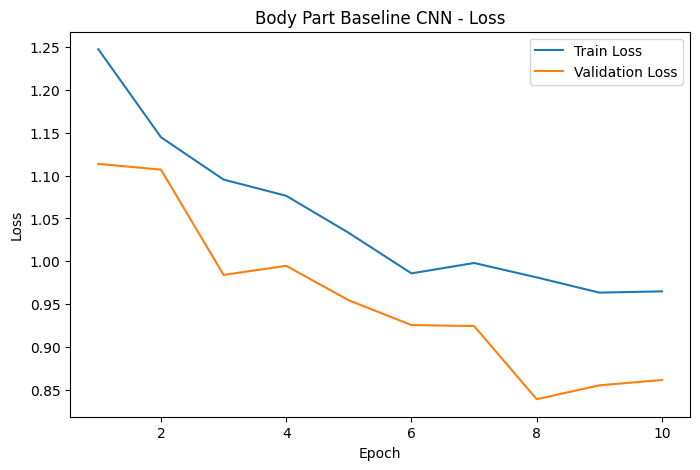

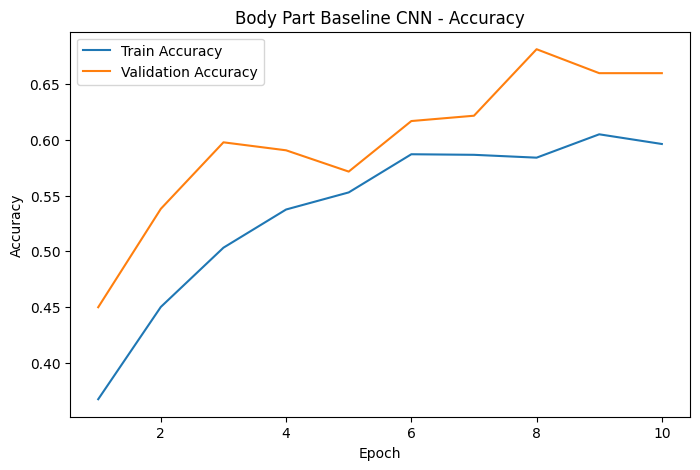

In [ ]:
plot_training_history(resnet_history, "ResNet18 Transfer Learning")

**Evaluate on test set**

In [ ]:
resnet_test_loss, resnet_test_acc, resnet_y_true, resnet_y_pred = evaluate_model(
    model=resnet_model,
    data_loader=body_test_loader,
    criterion=resnet_criterion,
    device=device
)

print("ResNet18 Test Loss:", resnet_test_loss)
print("ResNet18 Test Accuracy:", resnet_test_acc)

Test Loss: 0.9854630673582934
Test Accuracy: 0.5961995249406176


In [ ]:
body_part_class_names = ["Head", "Foot", "Torso", "Udder"]

print(classification_report(
    resnet_y_true,
    resnet_y_pred,
    target_names=body_part_class_names
) )

              precision    recall  f1-score   support

        Head       0.59      0.67      0.63       138
        Foot       0.00      0.00      0.00        23
       Torso       0.55      0.69      0.61       150
       Udder       0.73      0.49      0.59       110

    accuracy                           0.60       421
   macro avg       0.47      0.46      0.46       421
weighted avg       0.58      0.60      0.58       421



c:\Users\ezzyo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ezzyo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ezzyo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

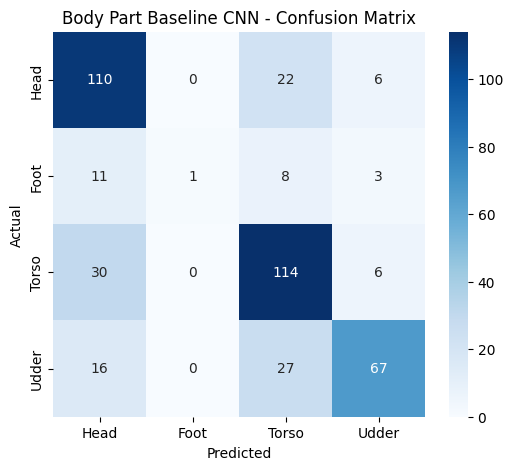

In [ ]:
resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    xticklabels=body_part_class_names,
    yticklabels=body_part_class_names,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 - Confusion Matrix")
plt.show()

**Save ResNet18 model**

In [ ]:
MODEL_DIR = BASE_DIR / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

resnet_model_path = MODEL_DIR / "resnet18_body_part.pth"

torch.save(resnet_model.state_dict(), resnet_model_path)

print("Saved ResNet18 model to:", resnet_model_path)

Saved baseline model to: /kaggle/working/saved_models/body_part_baseline_cnn.pth
